# # ML - 지도학습 - Regression 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : 다양한 머신러닝 기법을 활용한 주택가격 예측 모델 개발
- 분석 단위 : 주거 지역 (동네 수준의 생활권)
- 종속 변수 : 주택 중위가격 (median_house_value)
- 설명 변수 : 지역의 인구·주택 정보 (인구수, 가구수, 주택 연식, 방 개수 등)

[주요 실습 내용]
- 선형 회귀
- 의사결정나무
- Random Forest
- XGBoost
- LightGBM


# 데이타 준비
- 분석 데이타 : 캘리포니아 집값 데이터셋
- 데이타 설명 : 캘리포니아의 작은 지역(Census Block Group)별 인구·주택 정보를 이용하여 주택 가격를 예측하기 위함
- 변수 설명

| 컬럼명                | 한글명      | 의미                      | 비고               |
| ------------------ | -------- | ----------------------- | ---------------- |
| longitude          | 경도       | 해당 지역의 경도               | 연속형              |
| latitude           | 위도       | 해당 지역의 위도               | 연속형              |
| housing_median_age | 주택 중위 연식 | 해당 지역 주택의 중위 연식(년)      | 연속형              |
| total_rooms        | 전체 방 개수  | 해당 지역의 전체 방(Room) 수     | 연속형              |
| total_bedrooms     | 전체 침실 개수 | 해당 지역의 전체 침실(Bedroom) 수 | 연속형              |
| population         | 인구수      | 해당 지역의 총 인구수            | 연속형              |
| households         | 가구수      | 해당 지역의 총 가구 수           | 연속형              |
| median_income      | 중위소득     | 해당 지역 가구의 중위소득          | 연속형              |
| ocean_proximity    | 바다와의 거리  | 해당 지역의 바다와의 위치 관계       | **범주형**          |
| median_house_value | 주택 중위가격  | 해당 지역의 주택 중위가격(달러)      | **종속변수(Target)** |

- ocean_proximity 값 의미

| 값            | 의미           |
| ------------ | ------------ |
| `<1H OCEAN`  | 바다까지 1시간 이내  |
| `INLAND`     | 내륙 지역        |
| `NEAR OCEAN` | 바다 인접 지역     |
| `NEAR BAY`   | 만(Bay) 인접 지역 |
| `ISLAND`     | 섬 지역         |






데이타 불러오기

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")  # 경고 메시지 무시
url = "https://raw.githubusercontent.com/ageron/handson-ml2/master/datasets/housing/housing.csv"
df = pd.read_csv(url)
df

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
...,...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0,INLAND
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0,INLAND
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0,INLAND
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0,INLAND


컬럼정보 확인

In [15]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.7 MB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [16]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


범주형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [17]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[ocean_proximity]
                 count  ratio_%
ocean_proximity                
<1H OCEAN         9136    44.26
INLAND            6551    31.74
NEAR OCEAN        2658    12.88
NEAR BAY          2290    11.09
ISLAND               5     0.02


# 데이타 분할

X, y 분리

In [18]:
# X, y 분리
X = df.drop('median_house_value', axis=1)
y = df['median_house_value']

Data Partition
- 목적 : 모델이 학습에 사용하지 않은 새로운 데이터에서도 잘 동작하는지 검증하기 위함
 - Train  : Test 비율 (7 : 3)
- Train Set : 모델 학습용, Test Set : 모델 평가용
- 데이타 변환시 변환 통계량은 Train 데이터에서 계산하고, Test 데이터에는 그 기준을 적용해야 함 (Data Leakage 문제)

In [19]:
from sklearn.model_selection import train_test_split

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Transformation

Missing 처리
- 연속형: 중앙값 대체

In [20]:
import numpy as np
import pandas as pd

# 연속형 변수 선택
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Train 기준 중앙값 계산
median_values = X_train[num_cols].median()

# Train, Test 모두 Train 기준 중앙값으로 대체
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

- 범주형: New Class 대체

In [21]:
# 범주형 변수 선택
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# 신규 범주(Unknown)로 대체
for col in cat_cols:

    # Train
    if X_train[col].dtype.name == "category":
        X_train[col] = X_train[col].cat.add_categories("Unknown")
    X_train[col] = X_train[col].fillna("Unknown")

    # Test
    if X_test[col].dtype.name == "category":
        X_test[col] = X_test[col].cat.add_categories("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")

Scaling
   - Min-Max Scaling

In [9]:
from sklearn.preprocessing import MinMaxScaler

# 연속형 변수 추출
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

# Min-Max Scaling
scaler = MinMaxScaler()

# Train
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

 # Test
X_test[num_cols] = scaler.transform(X_test[num_cols])

범주형 변수 -> 수치형 변수로 변환
- One-hot Encoding

In [22]:
# 범주형 변수 선택
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# Train Set
X_train = pd.get_dummies(
    X_train,
    columns=cat_cols,
    drop_first=True      # False : One-Hot Encoding, True : Dummy Encoding(k-1)
)

# Test Set
X_test = pd.get_dummies(
    X_test,
    columns=cat_cols,
    drop_first=True
)

# Test를 Train 컬럼 구조에 맞춤
X_test = X_test.reindex(
    columns=X_train.columns,
    fill_value=0
)

# 선형 회귀
   - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html

   학습 및 예측

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = LinearRegression()

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 28.555
Test  MAPE: 28.953


# 의사결정나무
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html  


학습 및 예측

In [24]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = DecisionTreeRegressor(
    max_depth=3,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 31.393
Test  MAPE: 31.715


Tree 시각화

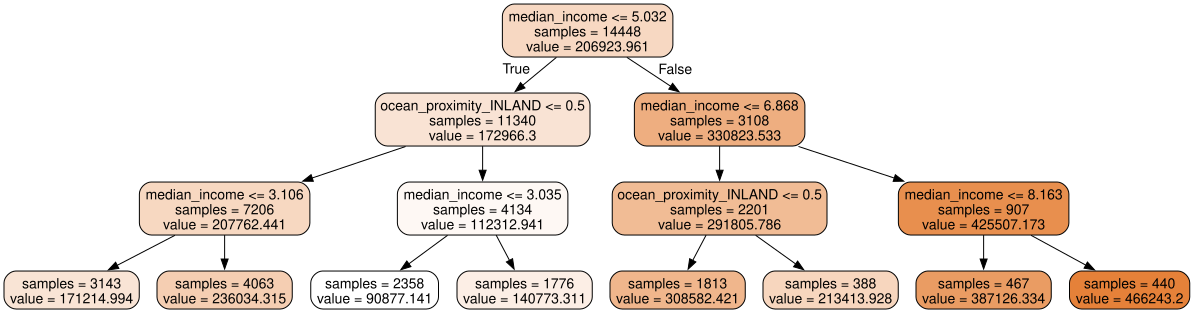

In [25]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    impurity=False,      # squared_error 미표시
    proportion=False     # 건수 기준 출력
)

graphviz.Source(dot_data)

### [Self-Practice]

- 실습 주제 : Tree 시각화로 의사결정 경로 추적하기
- 실습 조건
   - DecisionTreeRegressor 에서 max_depth=4 로 설정
- 실습 시나리오
   - 시나리오 1) max_depth=3일 경우와 max_depth=4일 경우의 Test MAPE를 비교하세요.
   - 시나리오 2) 주택 가격이 가장 높은 집단과 가장 낮은 집단 (노드)의 규칙(Rule)을 각각 도출하세요. 단, Scaling 을 적용하지 않은 상태에서 규칙을 도출하세요.

In [77]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = DecisionTreeRegressor(
    max_depth=16,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 6.278
Test  MAPE: 22.667


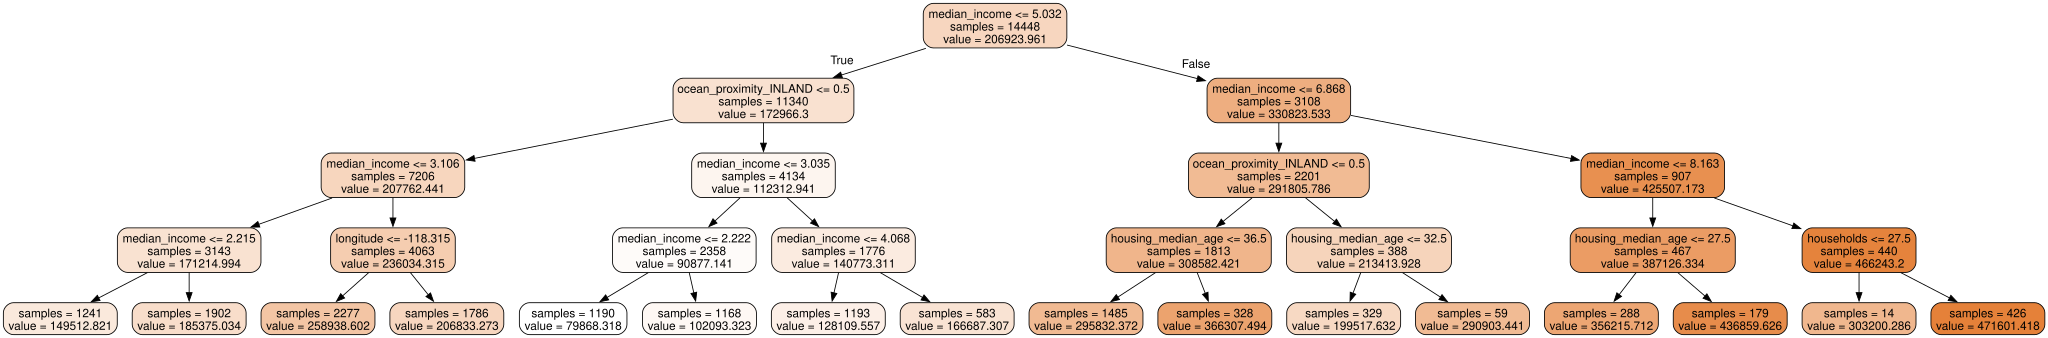

In [30]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    filled=True,
    rounded=True,
    impurity=False,      # squared_error 미표시
    proportion=False     # 건수 기준 출력
)

graphviz.Source(dot_data)

Feature Importance

                       Feature  Importance
7                median_income    0.725182
8       ocean_proximity_INLAND    0.227556
0                    longitude    0.023050
2           housing_median_age    0.020952
6                   households    0.003260
1                     latitude    0.000000
3                  total_rooms    0.000000
4               total_bedrooms    0.000000
5                   population    0.000000
9       ocean_proximity_ISLAND    0.000000
10    ocean_proximity_NEAR BAY    0.000000
11  ocean_proximity_NEAR OCEAN    0.000000


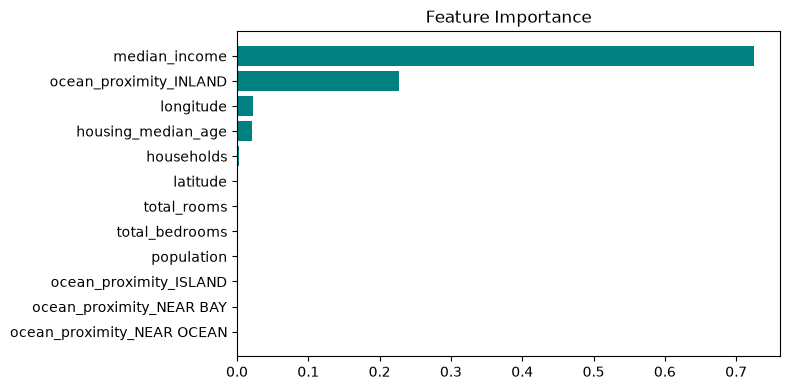

In [31]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# Random Forest
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

학습 및 예측

In [79]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = RandomForestRegressor(
    n_estimators=16,       # 트리 개수
    max_depth=12,            # 각 트리의 최대 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 14.269
Test  MAPE: 19.468


Feature Importance

                       Feature  Importance
7                median_income    0.688524
8       ocean_proximity_INLAND    0.219048
0                    longitude    0.032437
2           housing_median_age    0.026203
1                     latitude    0.024037
4               total_bedrooms    0.004199
3                  total_rooms    0.001908
6                   households    0.001884
5                   population    0.001662
11  ocean_proximity_NEAR OCEAN    0.000081
10    ocean_proximity_NEAR BAY    0.000017
9       ocean_proximity_ISLAND    0.000000


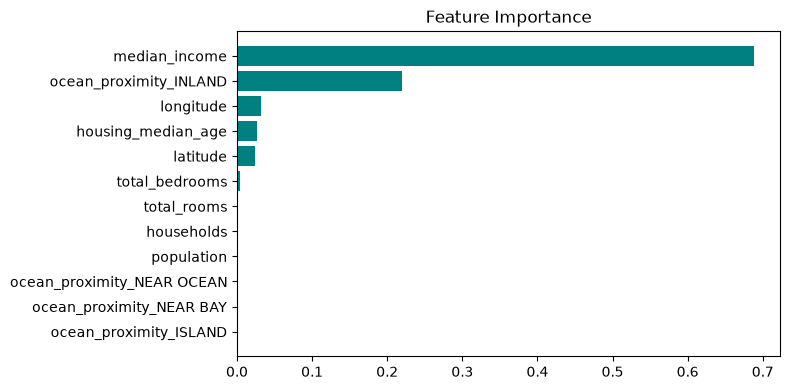

In [33]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

#  XGBoost
  - API 문서 : https://xgboost.readthedocs.io/en/stable/parameter.html

학습 및 예측

In [57]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = XGBRegressor(
    n_estimators=400,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 1.358
Test  MAPE: 16.819


#  LightGBM
  - API 문서 : https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

학습 및 예측

In [62]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error

# 모델 정의
model = LGBMRegressor(
    n_estimators=400,
    max_depth=10,
    learning_rate=0.1,
    random_state=42,
    verbosity=-1      # 로그 출력 안 함
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train MAPE: {mean_absolute_percentage_error(y_train, train_pred) * 100:.3f}")
print(f"Test  MAPE: {mean_absolute_percentage_error(y_test, test_pred) * 100:.3f}")

Train MAPE: 11.608
Test  MAPE: 16.820


### [Self-Practice]
Q) 모델별 하이퍼파라미터를 직접 변경하며 Test MAPE를 비교하고, 가장 우수한 성능을 보이는 모델과 하이퍼파라미터 조합을 찾으세요. 단, 하이퍼파라미터 자동 최적화 기법은 사용하지 않음